# 7DT medium-band photometry with supplied filter curves

> ⚠️ **Experimental.** A research demonstration using experimental APIs that may change between releases.

7DT observes through 20 medium bands on a 25 nm grid, `m400`–`m875`, plus
`g`, `r`, `i`. The curves are total system response, so detector QE and optics
are already in them. Photometry arrives as counts in ADU with a per-band AB
zeropoint.

Registration, prediction, and a fit. The 23 bands ship as `7dt_*`; the first
half registers them from files anyway, which is the path for any instrument
tengri does not carry.

In [1]:
from _setup import effective_wavelengths_um, quiet

quiet()

import os

os.environ["TENGRI_HOST_DEVICES"] = "4"  # enable parallel chain execution on 4 devices

import tempfile
import textwrap
import warnings
from pathlib import Path
from time import perf_counter

import jax
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    DEFAULT,
    FREE,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    builders,
    generate_mock,
    plot,
)
from tengri.inference.catalog_ingest import ingest_catalog
from tengri.observation.filters import load_filter
from tengri.observation.filters.custom import (
    register_filter,
    register_filter_from_file,
    unregister_filter,
)

plot.setup_style()

C_DATA, C_MODEL = "#c3372a", "#3a76d9"
WORK = Path(tempfile.mkdtemp(prefix="tengri_filters_"))

## The curve files

One CSV per band, `lam,trans`, wavelength in nanometers, zero-padded across
the instrument range. Comma or whitespace, header or not, `#` comments
stripped; the extension is not consulted.

In [2]:
lam_nm = np.arange(300.0, 1000.1, 0.1)
trans = 0.34 * np.exp(-0.5 * ((lam_nm - 401.0) / 10.3) ** 2)

delivered = WORK / "m400.csv"
delivered.write_text(
    "lam,trans\n" + "\n".join(f"{w:.5f},{t:.5f}" for w, t in zip(lam_nm, trans, strict=True))
)
print(delivered.read_text()[:64].replace("\n", " | "))

lam,trans | 300.00000,0.00000 | 300.10000,0.00000 | 300.20000,0.00000 | 


## Registering

Three routes, all resolving through `load_filter`. A registered name works
anywhere a built-in one does, and shadows a built-in of the same name.

In [3]:
# From arrays.
register_filter("demo_arrays", lam_nm, trans, wave_unit="nm", overwrite=True)

# From a file.
register_filter_from_file("demo_file", delivered, wave_unit="nm", overwrite=True)

fc = load_filter("demo_arrays")
print(f"{fc.wave.min():.0f}-{fc.wave.max():.0f} AA, peak T = {fc.trans.max():.3f}")
print(f"file route identical: {np.allclose(load_filter('demo_file').wave, fc.wave)}")

3000-10000 AA, peak T = 0.340
file route identical: True


`$TENGRI_FILTER_DIR` is a `:`-separated directory list searched by file stem,
with no code call. It resolves on any machine holding the directory, where the
in-memory routes last one process. It carries no unit metadata, so files there
are read as Angstrom.

In [4]:
filter_dir = WORK / "curves"
filter_dir.mkdir(exist_ok=True)
np.savetxt(filter_dir / "m400_dir.dat", np.column_stack([lam_nm * 10.0, trans]))
os.environ["TENGRI_FILTER_DIR"] = str(filter_dir)

print(f"by stem: {load_filter('m400_dir').wave.max():.0f} AA")

by stem: 10000 AA


## Units

Tengri is Angstrom throughout. `wave_unit` takes `"AA"`, `"nm"`, `"um"` and
converts on registration.

Omitted, a range check warns when a curve lies entirely between 100 Å and
1340 Å, which the opacity of the ISM leaves empty of bandpasses. It does not
see microns: an optical curve in microns lands at 0.5–0.7 Å, where real X-ray
bands are, and it stays quiet past 1340 nm.

In [5]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    register_filter("demo_unstated", lam_nm, trans, overwrite=True)

print(textwrap.fill(str(caught[0].message), 88) if caught else "no warning")

unstated = load_filter("demo_unstated")
print(f"\nunstated: {unstated.wave.min():.0f}-{unstated.wave.max():.0f} AA")
print(f"nm      : {fc.wave.min():.0f}-{fc.wave.max():.0f} AA")

for name in ("demo_arrays", "demo_file", "demo_unstated"):
    unregister_filter(name)
del os.environ["TENGRI_FILTER_DIR"]
unregister_filter("m400_dir")

Filter 'demo_unstated' custom filter spans 300-1000 Å, which lies entirely in the
extreme-UV (100-1340 Å). The ISM is opaque there, so no photometric bandpass exists in
that window -- these are most likely **nanometers**. If so, multiply by 10: 300-1000 nm
-> 3000-10000 Å. tengri wavelengths are Angstrom throughout. Pass wave_unit='nm' to
convert at the boundary instead of relying on this check.

unstated: 300-1000 AA
nm      : 3000-10000 AA


## The band set

Switching to the shipped curves for the rest.

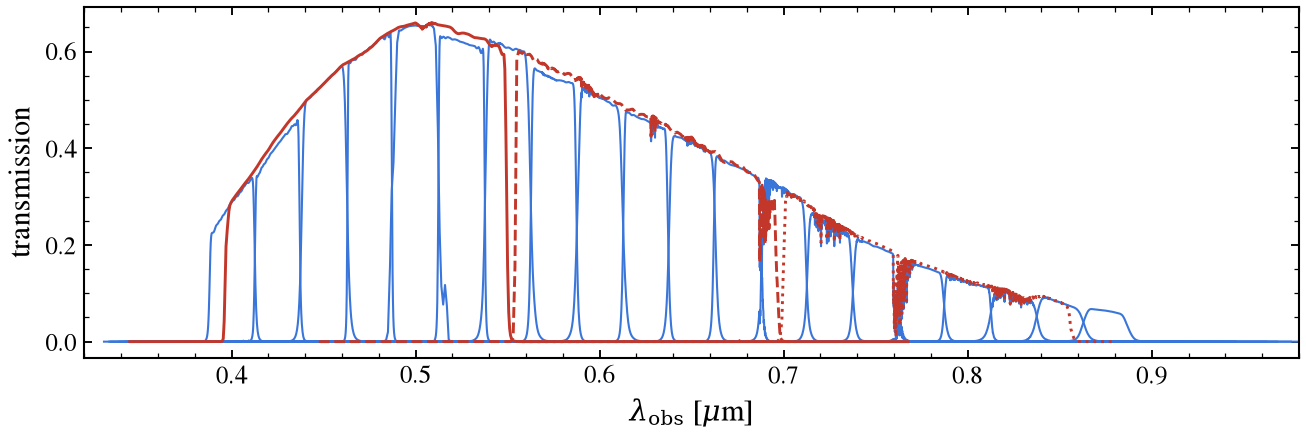

In [6]:
BANDS_MEDIUM = [f"7dt_m{lam}" for lam in range(400, 900, 25)]
BANDS_BROAD = ["7dt_g", "7dt_r", "7dt_i"]
FILTERS = BANDS_MEDIUM + BANDS_BROAD

fig, ax = plt.subplots(figsize=(9.0, 3.2))
for name in BANDS_MEDIUM:
    curve = load_filter(name)
    ax.plot(np.asarray(curve.wave) / 1e4, np.asarray(curve.trans), lw=1.0, color=C_MODEL)
for name, ls in zip(BANDS_BROAD, ["-", "--", ":"], strict=True):
    curve = load_filter(name)
    ax.plot(np.asarray(curve.wave) / 1e4, np.asarray(curve.trans), lw=1.4, ls=ls, color=C_DATA)
ax.set(xlabel=r"$\lambda_{\rm obs}$ [$\mu$m]", ylabel="transmission", xlim=(0.32, 0.98))
fig.tight_layout()

Peak transmission runs 0.34 at `m400` to 0.66 near 500 nm to 0.07 at `m875`.
That envelope is the QE. It cancels in AB photometry, where only the shape of
$T$ enters, and would matter for absolute count rates.

## Prediction

In [7]:
SSP_NAME = "prsc_miles_chabrier_wNE"
ssp = tengri.load_ssp(SSP_NAME, download=True)
obs = Observation(photometry=Photometry.from_names(FILTERS))

sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=WavePrecomp(),
    sfh=builders.sfh.tsnorm(all_params=FREE),
    dust_attenuation=builders.dust.two_component(
        all_params=Fixed(DEFAULT), law="calzetti", tau_diff=Uniform(0.0, 1.0)
    ),
    dust_emission=builders.dust.emission.modified_blackbody(all_params=Fixed(DEFAULT)),
    neb={"type": "ssp"},
    met={"logzsol": Uniform(-1.5, 0.3)},
    redshift=Fixed(0.0062),
)
forward = ForwardModel.build(sed=sed_model)
print(f"free parameters ({sed_model.spec.n_free}): {', '.join(sed_model.spec.free_params)}")

src/tengri/components/stellar/sps/dsps_wrapper.py:384: UserWarning: 'ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5' is a wNE (with-Nebular-Emission) SSP: nebular continuum and lines are already baked into the templates at fixed logU/logZ_gas. Pair it with the default baked-in nebular backend only: adding neb={'type': 'cue'} or a CLOUDY grid on top double-counts nebular emission.
  return load_ssp_data(str(candidate))


free parameters (7): dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_skew, sfh_tsnorm_trunc, sfh_tsnorm_width_gyr


`predict_photometry` returns one flux per band in the order named. This is the
surface the likelihood calls.

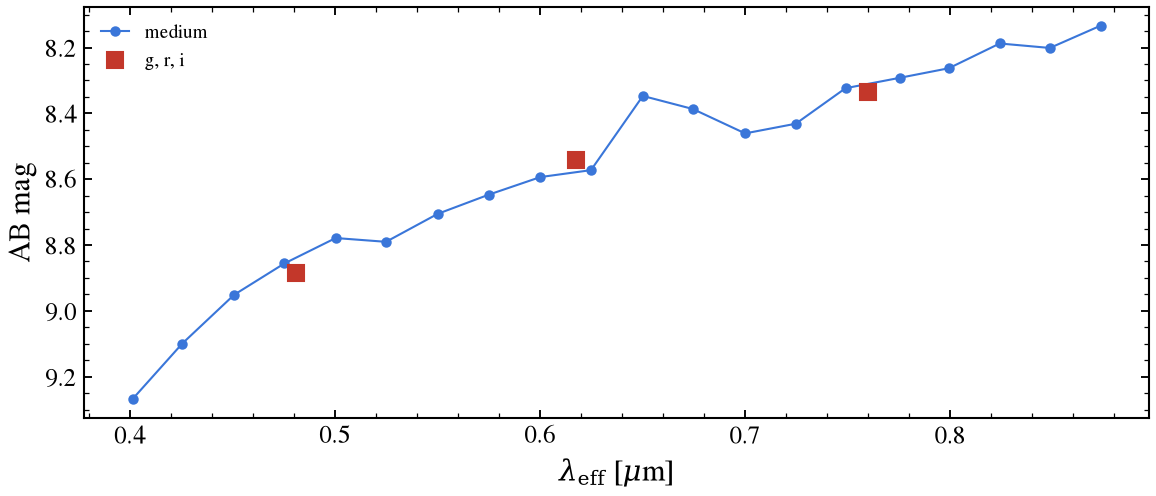

In [8]:
key_truth, key_mock, key_fit = jax.random.split(jax.random.PRNGKey(11), 3)
truth = sed_model.spec.sample(key_truth)

fnu_pred = np.asarray(sed_model.predict_photometry(truth))
mag_pred = -2.5 * np.log10(fnu_pred) - 48.60
wave_um = effective_wavelengths_um(obs.photometry)

n_med = len(BANDS_MEDIUM)
fig, ax = plt.subplots(figsize=(8.0, 3.6))
ax.plot(wave_um[:n_med], mag_pred[:n_med], "o-", ms=4, lw=1.0, color=C_MODEL, label="medium")
ax.plot(wave_um[n_med:], mag_pred[n_med:], "s", ms=8, color=C_DATA, label="g, r, i")
ax.invert_yaxis()
ax.set(xlabel=r"$\lambda_{\rm eff}$ [$\mu$m]", ylabel="AB mag")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()

## Fit

ADU and a zeropoint reach an ingestible unit in one step:

$$m_{\rm AB} = \mathrm{ZP}_b - 2.5\log_{10} f_{\rm ADU}, \qquad
  \sigma_m = 1.0857\,\sigma_f / f_{\rm ADU}.$$

There is no ADU `flux_unit`; a zeropoint is calibration, not a unit. The
counts below come from the model above, so the fit has a truth to miss.

In [9]:
ZP = dict.fromkeys(FILTERS, 23.89)  # per band in practice, near-identical here

mock = generate_mock(sed_model, truth, key=key_mock, snr=30.0)
fnu = np.asarray(mock["flux_obs"])
sigma = np.asarray(mock["noise"])

mag = -2.5 * np.log10(fnu) - 48.60
adu = 10.0 ** (-0.4 * (mag - np.array([ZP[b] for b in FILTERS])))
adu_err = adu * np.log(10.0) / 2.5 * (1.0857 * sigma / fnu)
print(f"ADU range: {adu.min():.0f} - {adu.max():.0f}")

ADU range: 670895 - 2077551


`ingest_catalog` takes the column names as they are, and the redshift column
explicitly.

In [10]:
mag_obs = np.array([ZP[b] for b in FILTERS]) - 2.5 * np.log10(adu)
mag_err = 1.0857 * adu_err / adu

table = {"redshift": np.array([0.0062])}
for j, band in enumerate(FILTERS):
    table[f"flux_{band}"] = np.array([mag_obs[j]])
    table[f"err_{band}"] = np.array([mag_err[j]])

arrays = ingest_catalog(
    table,
    photometry=obs.photometry,
    flux_unit="ab_mag",
    flux_cols=[f"flux_{b}" for b in FILTERS],
    err_cols=[f"err_{b}" for b in FILTERS],
    redshift_col="redshift",
)
print(f"round trip max |dF/F|: {np.abs(arrays.flux[0] / fnu - 1.0).max():.2e}")

round trip max |dF/F|: 1.07e-14


Zeropoint uncertainty is often already inside a delivered error column; adding
`NoiseModel(calibration_floor=...)` on top counts it twice. It is also shared
across every source in a band rather than drawn per source, which no per-fit
floor represents, and which matters when sources are fitted jointly or read as
a trend.

In [11]:
t0 = perf_counter()
posterior = forward.fit(arrays.flux[0], arrays.noise[0], key=key_fit, verbose=False)
print(f"Posterior fit: {perf_counter() - t0:.1f} s")

print(f"\n{'parameter':<20}{'truth':>12}{'p16':>12}{'p50':>12}{'p84':>12}")
print("-" * 68)
for pname in sed_model.spec.free_params:
    samples = np.asarray(posterior.samples[pname])
    p16, p50, p84 = np.percentile(samples, [16, 50, 84])
    true_val = float(truth[pname])
    print(f"{pname:<20}{true_val:>12.3f}{p16:>12.3f}{p50:>12.3f}{p84:>12.3f}")

Posterior fit: 58.0 s

parameter                  truth         p16         p50         p84
--------------------------------------------------------------------
dust_tau_diff              0.188       0.082       0.197       0.332
met_logzsol                0.092      -0.191       0.036       0.208
sfh_tsnorm_log_total_mass      11.432      11.405      11.485      11.547
sfh_tsnorm_peak_lbt_gyr       3.760       1.771       5.171       9.270
sfh_tsnorm_skew            0.389      -0.041       0.601       0.859
sfh_tsnorm_trunc           6.061       2.540       5.632       8.487
sfh_tsnorm_width_gyr       2.732       1.755       3.246       4.433


Mass and SFH width return tightly, metallicity and dust do not: 23 optical
bands with no UV and no infrared leave insufficient leverage in metallicity
and dust optical depth. See notebook 11 for population fitting via `Catalog`.